In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("UberDataset.csv")

In [3]:
# Convert datetime
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')

# Extract features
df['hour'] = df['START_DATE'].dt.hour
df['month'] = df['START_DATE'].dt.month

# Select required columns
df = df[['MILES', 'hour', 'month']]

# Drop null values
df.dropna(inplace=True)

df.head()

,MILES,hour,month
0,5.1,21.0,1.0
1,5.0,1.0,1.0
2,4.8,20.0,1.0
3,4.7,17.0,1.0
4,63.7,14.0,1.0


In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

C:\Users\VINU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\VINU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\VINU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\VINU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

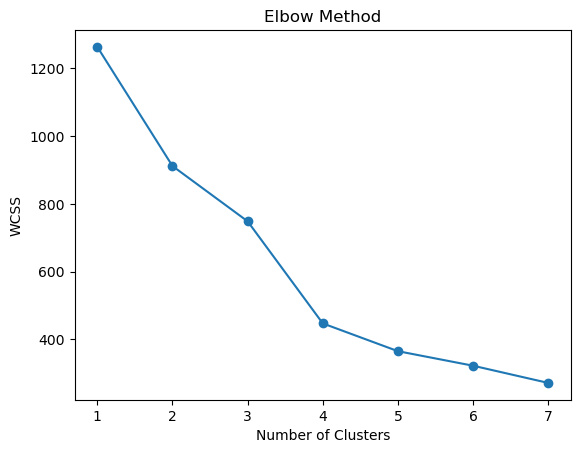

In [6]:
wcss = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 8), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

df.head()

C:\Users\VINU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,MILES,hour,month,Cluster
0,5.1,21.0,1.0,2
1,5.0,1.0,1.0,2
2,4.8,20.0,1.0,2
3,4.7,17.0,1.0,2
4,63.7,14.0,1.0,2


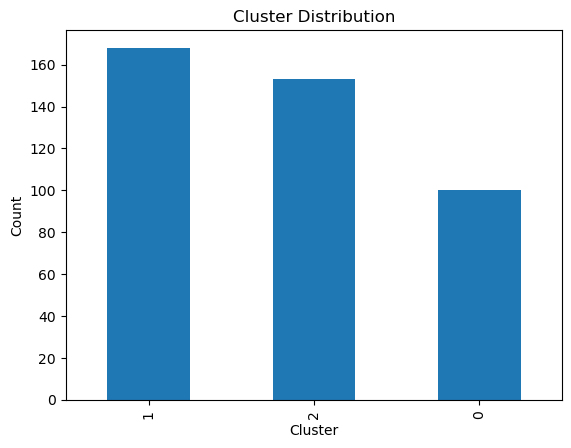

In [8]:
plt.figure()

df['Cluster'].value_counts().plot(kind='bar')

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.show()

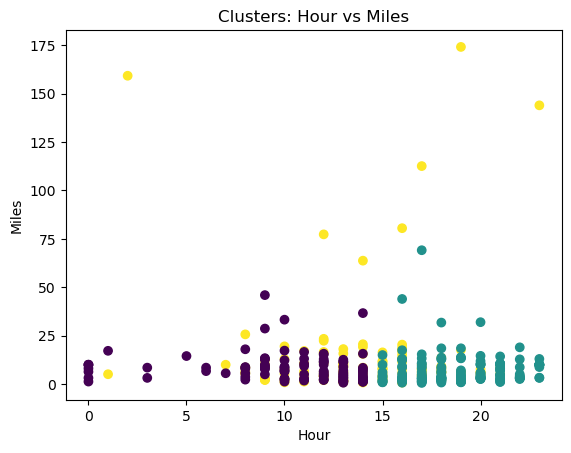

In [9]:
plt.figure()

plt.scatter(df['hour'], df['MILES'], c=df['Cluster'])

plt.title("Clusters: Hour vs Miles")
plt.xlabel("Hour")
plt.ylabel("Miles")

plt.show()

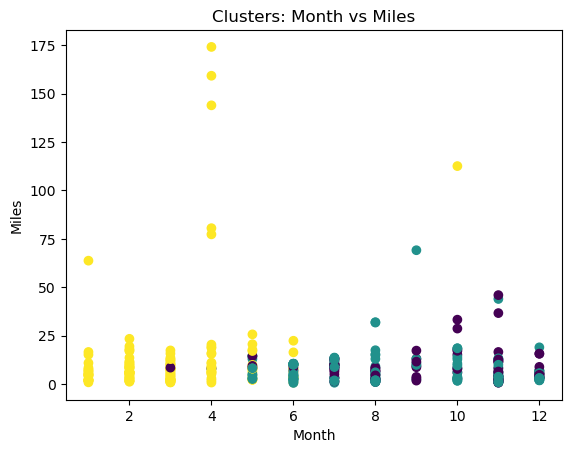

In [10]:
plt.figure()

plt.scatter(df['month'], df['MILES'], c=df['Cluster'])

plt.title("Clusters: Month vs Miles")
plt.xlabel("Month")
plt.ylabel("Miles")

plt.show()

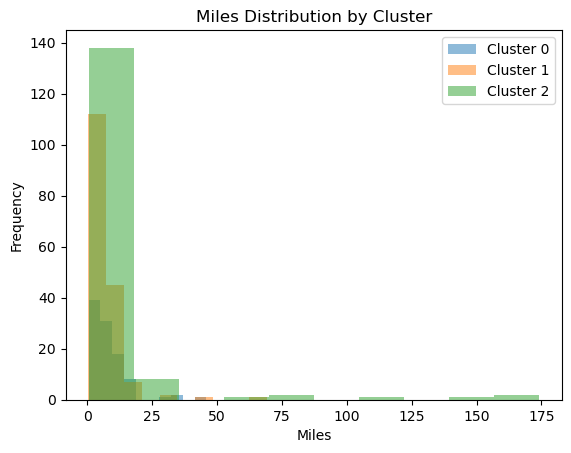

In [11]:
plt.figure()

for i in range(3):
    plt.hist(df[df['Cluster'] == i]['MILES'], alpha=0.5, label=f'Cluster {i}')

plt.title("Miles Distribution by Cluster")
plt.xlabel("Miles")
plt.ylabel("Frequency")
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

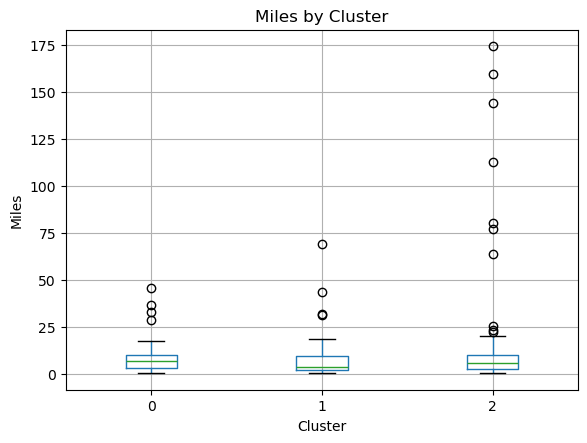

In [12]:
plt.figure()

df.boxplot(column='MILES', by='Cluster')

plt.title("Miles by Cluster")
plt.suptitle("")  # remove extra title

plt.xlabel("Cluster")
plt.ylabel("Miles")

plt.show()